# Ghigliottina — Tempo di generazione e token di ragionamento (dai log grezzi OpenRouter)

Fonte diversa dagli altri notebook: non l'Excel dei risultati, i backup
JSONL grezzi (`raw_logs/*.jsonl`) — servono perché contengono
`usage.completion_tokens_details.reasoning_tokens`, il conteggio nativo
di token di ragionamento fatturati da ciascun provider, mai scritto su
Excel. Domanda: la durata di generazione è spiegata dal numero di token
prodotti, o c'è dell'altro? E il testo di ragionamento che vediamo è
davvero tutto quello che è stato calcolato?

In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)

In [9]:
from pathlib import Path

RAW_LOGS_DIR = Path("D:/guillotine/guillotine/source/raw_logs")
JSONL_FILES = sorted(RAW_LOGS_DIR.glob("openrouter_*.jsonl"))
# Solo i log delle chiamate a temperatura controllata (openrouter_*) - i
# commerciali (commercial_*.jsonl) restano fuori apposta, hanno un solo
# run senza parametri, non lo stesso disegno sperimentale.
print(f"{len(JSONL_FILES)} file trovati:")
for p in JSONL_FILES:
    print(f"  {p.name}")

records = []
seen_calls = set()
n_duplicate = 0
for path in JSONL_FILES:
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            call_key = (r["model"], r["prompt_id"], r["temperature"], r["timestamp"])
            if call_key in seen_calls:
                n_duplicate += 1
                continue
            seen_calls.add(call_key)
            choices = r["response"].get("choices", [])
            if not choices:
                continue
            msg = choices[0].get("message", {}) or {}
            usage = r["response"].get("usage", {}) or {}
            details = usage.get("completion_tokens_details") or {}
            records.append({
                "model": r["model"], "prompt_id": r["prompt_id"], "temperature": r["temperature"],
                "duration_s": r["duration_s"], "completion_tokens": usage.get("completion_tokens"),
                "reasoning_tokens": details.get("reasoning_tokens"),
                "finish_reason": choices[0].get("finish_reason"),
                "reasoning_text_len": len(msg.get("reasoning") or ""),
                "content_text_len": len(msg.get("content") or ""),
            })

if n_duplicate:
    print(f"\n{n_duplicate} chiamate duplicate tra i file (stesso modello/item/temperatura/timestamp) - scartate.")

df = pd.DataFrame(records)
n_models = df['model'].nunique()
print(f"\n{len(df)} chiamate uniche, {n_models} modelli")
df.groupby("model").agg(n=("duration_s", "size"), reasoning_medio=("reasoning_tokens", "mean")).round(1)

16 file trovati:
  openrouter_20260820_115031.jsonl
  openrouter_20260820_120923.jsonl
  openrouter_20260820_130334.jsonl
  openrouter_20260820_131102.jsonl
  openrouter_20260820_131340.jsonl
  openrouter_20260821_111333.jsonl
  openrouter_20260821_141608.jsonl
  openrouter_20260821_154319.jsonl
  openrouter_20260822_100518.jsonl
  openrouter_20260823_083125.jsonl
  openrouter_20260824_052235.jsonl
  openrouter_20260825_051402.jsonl
  openrouter_20260826_060719.jsonl
  openrouter_20260827_074326.jsonl
  openrouter_20260827_084448.jsonl
  openrouter_20260829_100509.jsonl

5422 chiamate uniche, 64 modelli


,n,reasoning_medio
model,,
aion-labs/aion-3.0-mini,90,6454.8
amazon/nova-2-lite-v1,90,0.0
amazon/nova-micro-v1,90,0.0
arcee-ai/trinity-large-thinking,89,17972.9
bytedance-seed/seed-1.6-flash,88,3085.8
...,...,...
z-ai/glm-4.5-air,90,2684.3
z-ai/glm-4.6v,90,917.3
z-ai/glm-4.7,88,13328.0


## Chi ragiona davvero, chi no

Il campo `reasoning_tokens` è affidabile per questo: zero per i modelli
non-reasoning, non nullo/assente - una verifica diretta, non
un'inferenza dal nome del modello.

In [10]:
reasoning_means = df.groupby("model")["reasoning_tokens"].mean().sort_values(ascending=False)
print("Media reasoning_tokens per modello (0 = nessun ragionamento osservato):")
reasoning_means.round(1)

Media reasoning_tokens per modello (0 = nessun ragionamento osservato):


model
qwen/qwen3.7-flash                 24352.8
qwen/qwen3.5-122b-a10b             18431.4
z-ai/glm-4.7-flash                 18216.6
arcee-ai/trinity-large-thinking    17972.9
z-ai/glm-5.2:free                  16727.2
                                    ...   
openai/gpt-3.5-turbo                   0.0
openai/gpt-4o-mini                     0.0
sao10k/l3-lunaris-8b                   0.0
upstage/solar-pro-3                    0.0
upstage/solar-pro4                     0.0
Name: reasoning_tokens, Length: 64, dtype: float64

## Il testo di ragionamento visibile è completo, o è un riassunto?

Rapporto caratteri/token nel testo di `reasoning`: l'inglese normale ha
circa 4 caratteri per token. Un rapporto molto più basso indica che il
testo mostrato è più corto di quanto il conteggio fatturato implichi -
riassunto, non ragionamento integrale.

In [11]:
reasoning_models = reasoning_means[reasoning_means > 0].index.tolist()

density_rows = []
for m in reasoning_models:
    sub = df[(df["model"] == m) & (df["reasoning_tokens"] > 0) & (df["reasoning_text_len"] > 0)]
    if len(sub) < 3:
        continue
    density_rows.append({
        "model": m, "n": len(sub),
        "caratteri_per_token": (sub["reasoning_text_len"] / sub["reasoning_tokens"]).median(),
    })

density_df = pd.DataFrame(density_rows).sort_values("caratteri_per_token")
print("~4 car/token = testo completo mostrato. Molto sotto 4 = testo riassunto rispetto al calcolo reale.")
density_df.round(2)

~4 car/token = testo completo mostrato. Molto sotto 4 = testo riassunto rispetto al calcolo reale.


,model,n,caratteri_per_token
12,bytedance-seed/seed-2-1-turbo,90,0.89
0,qwen/qwen3.7-flash,90,3.49
4,z-ai/glm-5.2:free,4,3.65
1,qwen/qwen3.5-122b-a10b,88,3.65
7,qwen/qwen3.7-plus,89,3.68
23,bytedance-seed/seed-1.6-flash,88,3.76
19,xiaomi/mimo-v2.5,25,3.85
6,z-ai/glm-4.7,88,3.85
21,nvidia/nemotron-3-ultra-550b-a55b,87,3.87
13,inclusionai/ling-3.0-flash,90,3.87


## Durata spiegata dal numero di token: quanto, e a che velocità

Correlazione diretta (non solo un'ipotesi) tra `reasoning_tokens` e
`duration_s`, per modello - e il tasso secondi/token, che è una misura
comparabile di velocità pura di inferenza tra provider diversi.

In [12]:
rate_rows = []
for m in reasoning_models:
    sub = df[(df["model"] == m) & (df["reasoning_tokens"] > 50)]
    if len(sub) < 5:
        continue
    rho, p = stats.spearmanr(sub["reasoning_tokens"], sub["duration_s"])
    rate_rows.append({
        "model": m, "n": len(sub),
        "rho_token_durata": rho, "p_value": p,
        "s_per_token_mediana": (sub["duration_s"] / sub["reasoning_tokens"]).median(),
        "token_al_secondo": 1 / (sub["duration_s"] / sub["reasoning_tokens"]).median(),
    })

rate_df = pd.DataFrame(rate_rows).sort_values("s_per_token_mediana")
rate_df.round(4)

,model,n,rho_token_durata,p_value,s_per_token_mediana,token_al_secondo
29,liquid/lfm-2.5-2.6b:free,9,0.4667,0.2054,0.0047,211.2717
12,inclusionai/ling-3.0-flash,90,0.8886,0.0000,0.0053,186.9558
0,qwen/qwen3.7-flash,90,0.9921,0.0000,0.0058,173.3847
3,arcee-ai/trinity-large-thinking,89,0.9792,0.0000,0.0058,171.6580
21,stepfun/step-3.7-flash,37,0.9791,0.0000,0.0066,152.5830
10,qwen/qwen3-next-80b-a3b-thinking,90,0.9497,0.0000,0.0071,140.2549
22,bytedance-seed/seed-1.6-flash,88,0.9505,0.0000,0.0071,140.1443
13,nex-agi/nex-n2-mini,90,0.9602,0.0000,0.0089,112.1782
1,qwen/qwen3.5-122b-a10b,88,0.9216,0.0000,0.0100,100.1616
8,thinkingmachines/inkling-small,90,0.7612,0.0000,0.0104,96.1566


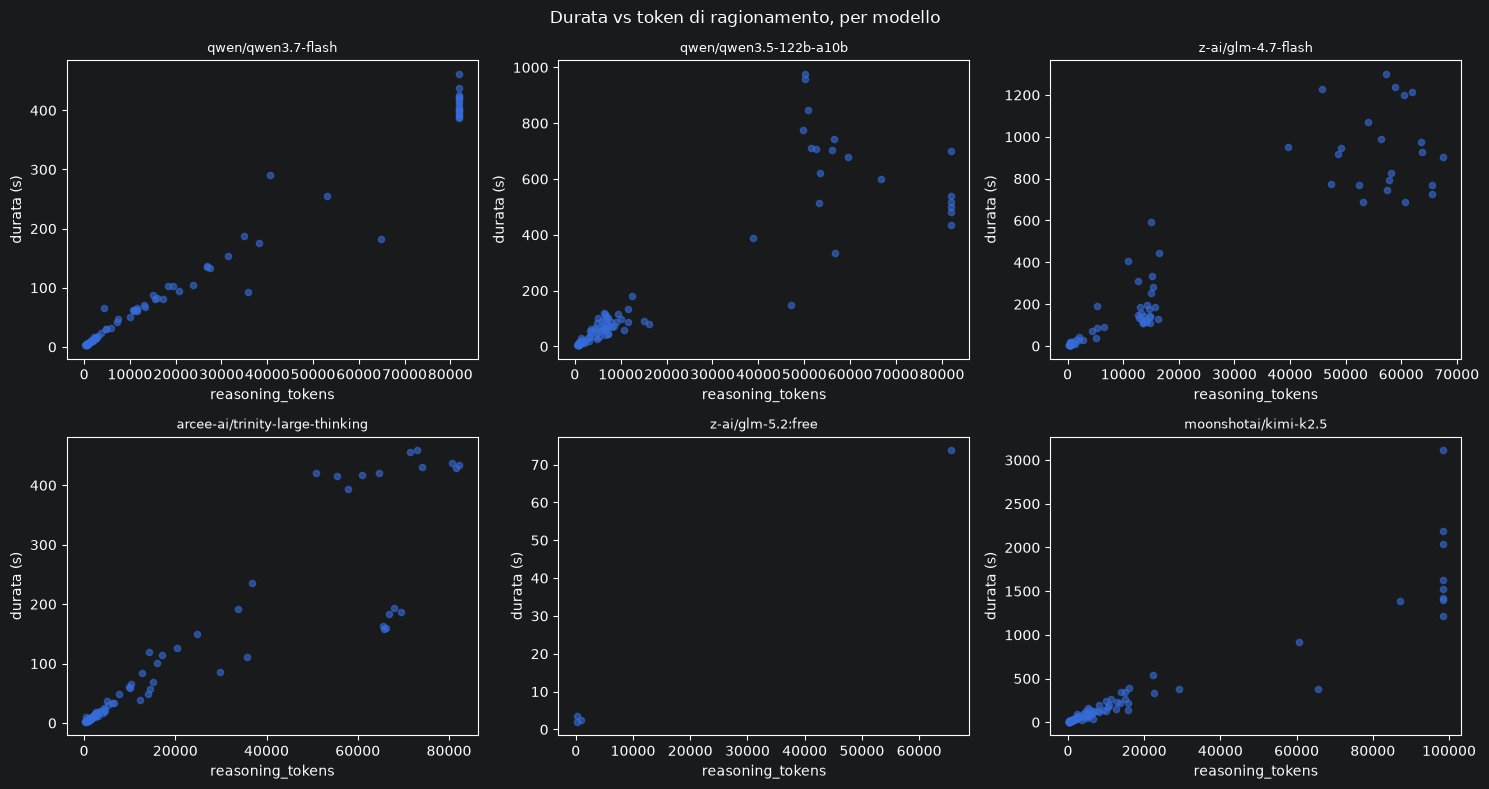

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)
for ax, m in zip(axes.flat, reasoning_models[:6]):
    sub = df[(df["model"] == m) & (df["reasoning_tokens"] > 0)]
    ax.scatter(sub["reasoning_tokens"], sub["duration_s"], alpha=0.6, s=20)
    ax.set_title(m, fontsize=9)
    ax.set_xlabel("reasoning_tokens")
    ax.set_ylabel("durata (s)")
plt.suptitle("Durata vs token di ragionamento, per modello")
plt.tight_layout()
plt.show()

## I casi al tetto (65.536 token, nessuna risposta)

Stesso fenomeno già documentato per `z-ai/glm-5.2` — modello che esaurisce
il budget massimo di generazione senza mai emettere una risposta finale.
Qui verificato su altri modelli, con `finish_reason` come conferma diretta
invece che dedotto dal solo clustering delle durate.

In [14]:
at_cap = df[df["reasoning_tokens"] >= 65536]
print(f"{len(at_cap)} chiamate al tetto massimo di token, nessuna risposta prodotta:")
at_cap[["model", "prompt_id", "finish_reason", "content_text_len"]]

80 chiamate al tetto massimo di token, nessuna risposta prodotta:


,model,prompt_id,finish_reason,content_text_len
103,z-ai/glm-5.2:free,guillo_01,length,0
603,nex-agi/nex-n2-mini,guillo_29,length,0
759,qwen/qwen3.7-flash,guillo_05,stop,5
763,qwen/qwen3.7-flash,guillo_09,stop,3
765,qwen/qwen3.7-flash,guillo_11,stop,6
...,...,...,...,...
5032,qwen/qwen3.5-122b-a10b,guillo_29,stop,150124
5036,qwen/qwen3.5-122b-a10b,guillo_03,stop,6
5041,qwen/qwen3.5-122b-a10b,guillo_09,stop,6
5060,qwen/qwen3.5-122b-a10b,guillo_29,stop,6


In [15]:
print("Item che ricorrono piu' volte tra i casi esauriti (probabile difficolta' strutturale, non casuale):")
at_cap["prompt_id"].value_counts()

Item che ricorrono piu' volte tra i casi esauriti (probabile difficolta' strutturale, non casuale):


prompt_id
guillo_09    13
guillo_29    11
guillo_03     7
guillo_23     7
guillo_24     6
guillo_22     5
guillo_11     3
guillo_25     3
guillo_20     3
guillo_05     2
guillo_30     2
guillo_12     2
guillo_02     2
guillo_19     2
guillo_04     2
guillo_08     2
guillo_13     2
guillo_01     1
guillo_26     1
guillo_07     1
guillo_14     1
guillo_28     1
guillo_27     1
Name: count, dtype: int64

### Lettura

`guillo_09` (petrichor) compare tra i casi esauriti - lo stesso item che
Claude Opus 5 aveva risolto con successo (4.272 token, risultato
corretto). Due modelli diversi qui restano bloccati sullo stesso item
fino al tetto massimo, senza mai arrivare a una risposta. Vale la pena
tenerlo come controesempio diretto nel documento qualitativo: stesso
item, stesso principio (parola rara, poco rappresentata), esiti opposti
a seconda del modello - non è la rarità della parola a decidere da sola
il risultato, è come il modello specifico la gestisce.